In [ ]:
#carregando a base

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
url = "https://docs.google.com/spreadsheets/d/1XGXz2MQOiKGT8Hx40q8PElHdUSTugArkKWZm0H1Nssc/export?format=csv&gid=0"
df = pd.read_csv(url)
df.head()

,data,linha,turno,produtos_ok,produtos_defeituosos,tipo_defeito_principal,horas_trabalhadas,meta_diaria
0,2026-07-01,L1,A,333,10,Dimensional,7.6,320
1,2026-07-01,L1,B,324,13,Solda,7.9,320
2,2026-07-01,L1,C,307,15,Dimensional,7.5,320
3,2026-07-01,L2,A,296,23,Solda,7.8,320
4,2026-07-01,L2,B,265,23,Riscos,7.6,320


## 1 - análise inicial

In [ ]:
#para ver as primeiras 10 linhas

display(df.head(10))

#para ver as ultimas linhas

display(df.tail())

#contando linhas e colunas

linhas, colunas = df.shape
print(f'o dataframe possui {linhas} linhas e {colunas} colunas')

,data,linha,turno,produtos_ok,produtos_defeituosos,tipo_defeito_principal,horas_trabalhadas,meta_diaria
0,2026-07-01,L1,A,333,10,Dimensional,7.6,320
1,2026-07-01,L1,B,324,13,Solda,7.9,320
2,2026-07-01,L1,C,307,15,Dimensional,7.5,320
3,2026-07-01,L2,A,296,23,Solda,7.8,320
4,2026-07-01,L2,B,265,23,Riscos,7.6,320
5,2026-07-01,L2,C,258,23,Acabamento,7.7,320
6,2026-07-01,L3,A,378,19,Riscos,7.7,320
7,2026-07-01,L3,B,329,16,Acabamento,7.7,320
8,2026-07-01,L3,C,321,12,Pintura,7.8,320
9,2026-07-02,L1,A,346,11,Acabamento,7.8,320


,data,linha,turno,produtos_ok,produtos_defeituosos,tipo_defeito_principal,horas_trabalhadas,meta_diaria
265,2026-07-30,L2,B,297,19,Acabamento,7.5,320
266,2026-07-30,L2,C,260,26,Pintura,7.9,320
267,2026-07-30,L3,A,365,14,Riscos,7.8,320
268,2026-07-30,L3,B,352,15,Solda,8.0,320
269,2026-07-30,L3,C,320,22,Solda,7.8,320


o dataframe possui 270 linhas e 8 colunas


A base cobre um período de 30 dias e tem 270 linhas e 8 colunas

## 2 - diagnóstico de qualidade da base

In [ ]:
#tipo de cada coluna

df.dtypes

,0
data,object
linha,object
turno,object
produtos_ok,int64
produtos_defeituosos,int64
tipo_defeito_principal,object
horas_trabalhadas,float64
meta_diaria,int64


In [ ]:
#valores em branco

df.isnull().sum()

,0
data,0
linha,0
turno,0
produtos_ok,0
produtos_defeituosos,0
tipo_defeito_principal,0
horas_trabalhadas,0
meta_diaria,0


In [ ]:
#linhas duplicadas

df.duplicated().sum()

np.int64(0)

a base está pronta para ser analisada, pois está padronizada, sem valores em branco nem linhas duplicadas

## 3 - resumo estatístico geral

In [ ]:
#gerar o resumo estatístico

print('resumo estatístico geral: ')
print(df.describe())

resumo estatístico geral: 
       produtos_ok  produtos_defeituosos  horas_trabalhadas  meta_diaria
count   270.000000            270.000000         270.000000        270.0
mean    309.696296             16.122222           7.748889        320.0
std      34.882761              5.520818           0.145243          0.0
min     215.000000              5.000000           7.500000        320.0
25%     285.000000             12.000000           7.600000        320.0
50%     314.000000             15.000000           7.800000        320.0
75%     334.500000             20.000000           7.900000        320.0
max     387.000000             31.000000           8.000000        320.0


In [ ]:
#extraindo valores específicos da coluna produtos_ok

media = df['produtos_ok'].mean().round()
mediana = df['produtos_ok'].median()
minimo = df['produtos_ok'].min()
maximo = df['produtos_ok'].max()

print('média = ' , media)
print('mediana = ' , mediana)
print('mínimo = ' , minimo)
print('máximo = ' , maximo)

#verificando se a média alcança a meta de 320

if media >= 320:
  print('a meta de 320 produtos bons foi atingida, com ' , media , 'produtos bons' )
else:
  print('a meta de 320 não foi atingida, com ' , media , 'produtos bons' )



média =  310.0
mediana =  314.0
mínimo =  215
máximo =  387
a meta de 320 não foi atingida, com  310.0 produtos bons


## 4 - produção e refugo total do mês

In [ ]:
#total de peças boas produzidas

total_pecas_boas = df['produtos_ok'].sum()
print('o total de peças boas produzidas foi: ' , total_pecas_boas , 'peças')

#total de peças com defeito produzidas
total_pecas_ruins = df['produtos_defeituosos'].sum()
print('o total de peças ruins produzidas foi: ' , total_pecas_ruins , 'peças')

#total de peças produzidas
total_produzidas = (total_pecas_ruins + total_pecas_boas)
print('o total de peças produzidas foi : ' , total_produzidas , 'peças')

#calculo do refugo
taxa_refugo = (total_pecas_ruins / total_produzidas) * 100
if taxa_refugo < 5:
  print('a taxa de refugo está dentro do padrão de 5%, com: ' , taxa_refugo)
else:
  print(' a taxa de refugo está fora do padrão de 5%, com: ' . taxa_refugo)

o total de peças boas produzidas foi:  83618 peças
o total de peças ruins produzidas foi:  4353 peças
o total de peças produzidas foi :  87971 peças
a taxa de refugo está dentro do padrão de 5%, com:  4.948221573018381


## 5 -  ranking das linhas de produção

In [ ]:
#definindo os parâmetros do ranking das linhas

ranking_linhas = (df.groupby('linha')['produtos_ok']
                  .mean()
                  .sort_values(ascending=False)
                  .reset_index())

#formatando para uma tabela

ranking_linhas.columns = ['linha' , 'média de produtos bons']
print(ranking_linhas)

  linha  média de produtos bons
0    L3              339.700000
1    L1              315.222222
2    L2              274.166667


a linha 3 é a que tem a melhor média de produtos bons, enquanto a linha 2 está muito abaixo da média e muito menor que os outras linhas.

## 6 - comparação entre turnos

In [ ]:
#agrupa por turnos e calcula a média dos produtos bons e ruins

comparativo_turnos = (df.groupby('turno').agg({'produtos_ok': 'mean' , 'produtos_defeituosos' : 'mean'}).reset_index())

#formatando para uma tabela
comparativo_turnos.columns = ['turno' , 'média produtos bons' , 'média produtos ruins']
print(comparativo_turnos)

  turno  média produtos bons  média produtos ruins
0     A           325.955556             13.844444
1     B           312.177778             16.077778
2     C           290.955556             18.444444


o turno da noite (C) é o que menos produz produtos bons e mais produtos ruins (em média),. Já o turno da manhã (A) é o que mais produz produtos bons e menos produtos ruins.

7 - criando um indicador: taxa de refugo por turno

In [ ]:
#criar a coluna de total produzido

df['total_produzidas'] = df['produtos_ok'] + df['produtos_defeituosos']

#calcula taxa de refugo em porcentagem

df['taxa_refugo_pct'] = (df['produtos_defeituosos'] / df['total_produzidas']) * 100

#filtra e exibe as maiores taxas de refugo

df.nlargest(10 , 'taxa_refugo_pct')

,data,linha,turno,produtos_ok,produtos_defeituosos,tipo_defeito_principal,horas_trabalhadas,meta_diaria,total_produzidas,taxa_refugo_pct
104,2026-07-12,L2,C,233,28,Dimensional,7.7,320,261,10.727969
22,2026-07-03,L2,B,246,29,Pintura,7.6,320,275,10.545455
86,2026-07-10,L2,C,272,31,Pintura,7.9,320,303,10.231023
185,2026-07-21,L2,C,240,27,Acabamento,7.8,320,267,10.112360
230,2026-07-26,L2,C,253,28,Solda,7.6,320,281,9.964413
122,2026-07-14,L2,C,258,28,Riscos,7.9,320,286,9.790210
248,2026-07-28,L2,C,225,24,Acabamento,7.9,320,249,9.638554
50,2026-07-06,L2,C,264,28,Riscos,7.9,320,292,9.589041
67,2026-07-08,L2,B,227,24,Riscos,8.0,320,251,9.561753
77,2026-07-09,L2,C,253,26,Dimensional,8.0,320,279,9.318996


nos 10 piores casos, todos são da Linha 2 e quase todos são do turno da noite (C)

8 - gráfico de defeitos mais frequentes

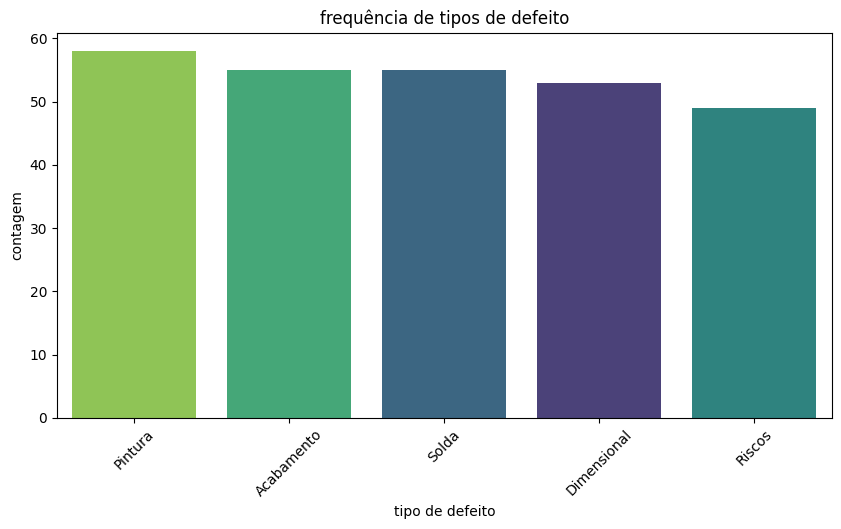

In [ ]:
#configura o tamanho da figura

plt.figure(figsize=(10,5))

#gráfico de barras ordenado pelos defeitos

sb.countplot(data=df,
             x = 'tipo_defeito_principal' ,
             hue = 'tipo_defeito_principal',
             order = df['tipo_defeito_principal'].value_counts().index,
             palette = 'viridis',
             legend = False)

#ajusta títulos e rótulos

plt.title('frequência de tipos de defeito')
plt.xlabel('tipo de defeito')
plt.ylabel('contagem')
plt.xticks(rotation=45)

plt.show()

a maioria dos defeitos são de pintura e acabamento e devem ser prioridade

9 -  cumprimento de meta por linha - boxplot comparativo

  linha  percentual meta atingida
0    L1                 42.222222
1    L2                  1.111111
2    L3                 80.000000


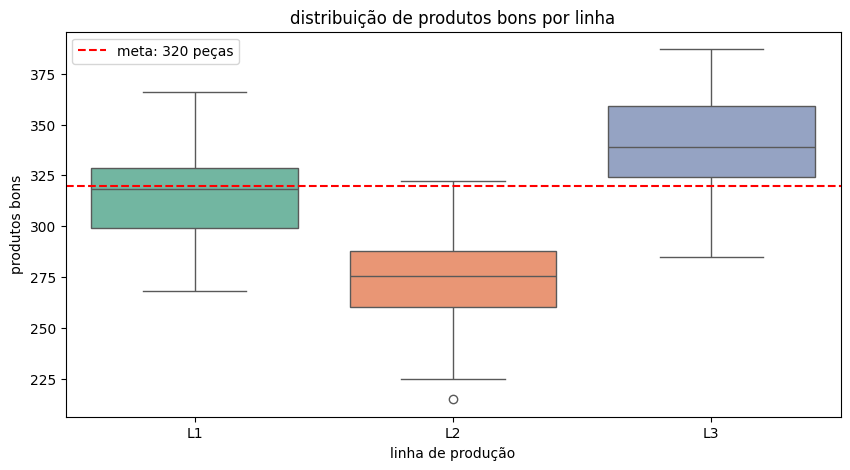

In [ ]:
# a - coluna atingiu meta

df['atingiu_meta'] = df['produtos_ok'] >= 320

#b - calculando o percentual de turnos que atingiram a meta, por linha

tabela_meta = (
    df.groupby("linha")["atingiu_meta"]
    .mean()
    .mul(100)
    .reset_index())

tabela_meta.columns = ["linha", "percentual meta atingida"]
print(tabela_meta)

# c gerando o boxplot comparativo

plt.figure(figsize=(10, 5))
sb.boxplot(
    data=df,
    x="linha",
    y="produtos_ok",
    hue="linha",
    legend=False,
    palette="Set2",
)
plt.axhline(
    320, color="red", linestyle="--", label="meta: 320 peças"
)  # Linha da meta
plt.title("distribuição de produtos bons por linha")
plt.xlabel("linha de produção")
plt.ylabel("produtos bons")
plt.legend()
plt.show()

a linha 3 é a que mais tem consistência, produzindo mais que a meta de 320 produtos bons. Enquanto isso, a linha 2 é mais inconsistente e produz muito menos que a meta.

10 - detecção de outliers - investigando o dia atípico

In [ ]:
#calculo de quartil

q1= df['total_produzidas'].quantile(0.25)
q3= df['total_produzidas'].quantile(0.75)
iqr = (q3 - q1)

#definição de limites dos outliers

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print(f"q1: {q1:.2f} | q3: {q3:.2f} | iqr: {iqr:.2f}")
print(f"limites para outliers: inferior = {limite_inferior:.2f} | superior = {limite_superior:.2f}\n")

#filtrando os turnos atípicos

outliers = df[
    (df["total_produzidas"] < limite_inferior)
    | (df["total_produzidas"] > limite_superior)
]
print(outliers)

q1: 303.00 | q3: 346.00 | iqr: 43.00
limites para outliers: inferior = 238.50 | superior = 410.50

           data linha turno  produtos_ok  produtos_defeituosos  \
239  2026-07-27    L2     C          215                    21   

    tipo_defeito_principal  horas_trabalhadas  meta_diaria  total_produzidas  \
239                Pintura                7.6          320               236   

     taxa_refugo_pct  atingiu_meta  
239         8.898305         False  
